# Craigslist listing price

## Project summary

- **Task:** predict **used-car listing price** (USD) from enriched Craigslist rows (`regex` + **LLM** ETL → master CSV in GCS, materialized as `listings_master_llm.csv`).
- **Modeling:** **time-aware** split (train on all local calendar days before the latest day; **holdout = latest day**).
- **This notebook:** reads **synced files under `results/` only**. Reproduce by running `train-dt` (not `dry_run`) and the **Sync model artifacts** workflow.

**Holdout metrics** (MAE, MAPE, RMSE, Bias) are always in **original dollars** (`actual_price` vs `pred_price`). If training used `log1p(price)`, predictions are **back-transformed with `expm1`** before metrics and `predictions.csv`.

## 1. Data and features

- **Source:** Craigslist car listings scraped to GCS; **regex** structured extract + **Vertex Gemini** enrichment; master table **`listings_master_llm.csv`**.
- **Key enriched fields** include make/model, mileage, year, transmission, fuel, drive, condition, title status, body type, seller type, location (city/state), and **`zip_prefix`** from a cleaned 5-digit ZIP (invalid ZIPs nulled).
- **Training filters** (before fitting): positive price in range, plausible model year vs scrape year, mileage cap (see **`max_mileage_cap`** in **`filtering`**), drop non-standard **title** rows (salvage / parts-only / missing) and **condition = project**. Counts are in **`metrics.json` → `filtering`**.
- **Numeric feature variants:** the trainer picks **A**, **B**, or **C** using a fixed **RandomForest + log target** probe on the **calendar validation day**: **A** = `vehicle_age` + `log_mileage` (+ cylinders); **B** = `year_num` + `mileage_num` (+ cylinders); **C** = full numeric set (may include redundant pairs if validation improves). See **`benchmark.feature_variant`** in **`metrics.json`**.

## 2. Modeling strategy

- **Time-aware split:** `scraped_at` → **`America/New_York` local date**. **Train** = all days **before** the latest day; **holdout** = **latest** day only (main evaluation).
- **Calendar validation:** if **≥3** distinct local dates, the **second-latest** day benchmarks every **(model × target)** pair on the **same** rows so comparison is fair and forward-looking.
- **Models:** `DecisionTreeRegressor`, `RandomForestRegressor`, `ExtraTreesRegressor`, `HistGradientBoostingRegressor`.
- **Targets:** **`price_num` (raw)** vs **`log1p(price_num)`**. Validation and holdout errors for grading are in **USD** after **`expm1`** when the model was trained on log price.
- **Ranking:** default-params results are ordered by **`val_composite` = MAE + w_rmse×RMSE + w_bias×|bias|`** (see **`metrics.json` → `benchmark.validation_ranking`**). **MAPE** is shown but **not** used to pick the winner (it is unstable when many cheap cars appear).
- **Tuning:** the **top two** **(model, target)** pairs by that ranking are tuned with **`ParameterSampler`** on the same validation day; the **winner** is refit on **all** pre-holdout rows, then scored once on the **latest** holdout.

**Why not random K-fold?** Listing mix and price levels shift by day; random splits can leak future-like patterns. Calendar validation + holdout better match deployment.


In [103]:
# Repo root: Colab shallow-clone, or local checkout with ./results
import os
import sys

DEFAULT_REPO = "https://github.com/OPIM5512-mjb24001/myscrapers-mjb24001-v3.git"
REPO_URL = os.environ.get("NOTEBOOK_REPO_URL", DEFAULT_REPO)
BRANCH = os.environ.get("NOTEBOOK_REPO_BRANCH", "main")

if "google.colab" in sys.modules:
    import subprocess

    subprocess.run(["rm", "-rf", "repo"], check=False)
    subprocess.run(
        ["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, "repo"],
        check=True,
    )
    os.chdir("repo")
    print(f"Cloned: {REPO_URL} (branch {BRANCH})")
else:
    if os.path.isdir("results"):
        print("Using current directory as repo root (./results found).")
    elif os.path.isdir(os.path.join("..", "results")):
        os.chdir("..")
        print("Using parent directory as repo root.")
    else:
        print(
            "Tip: run from the repository root so ./results exists, or use Colab to clone."
        )

Cloned: https://github.com/OPIM5512-mjb24001/myscrapers-mjb24001-v3.git (branch main)


In [104]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display, Image, Markdown
except ImportError:
    display = print
    Image = None

    def Markdown(x):
        print(x)


ROOT = Path(".").resolve()
RESULTS = ROOT / "results"
METRICS_DIR = RESULTS / "metrics"


def latest_run_id() -> str | None:
    if not METRICS_DIR.is_dir():
        return None
    files = sorted(METRICS_DIR.glob("*-metrics.json"))
    if not files:
        return None
    return files[-1].stem.replace("-metrics", "")


run_id = latest_run_id()
metrics_path = METRICS_DIR / f"{run_id}-metrics.json" if run_id else None
model_info_path = METRICS_DIR / f"{run_id}-model_info.json" if run_id else None
bench_csv_path = METRICS_DIR / f"{run_id}-model_benchmark.csv" if run_id else None

metrics = {}
if metrics_path and metrics_path.is_file():
    try:
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    except Exception as e:
        print(f"Could not parse metrics JSON: {e}")
        metrics = {}

if run_id:
    display(Markdown(f"**Latest synced run_id:** `{run_id}`"))
else:
    display(
        Markdown(
            "_No `results/metrics/*-metrics.json` found. Train (not dry_run) and run **Sync model artifacts**."
        )
    )

**Latest synced run_id:** `2026040619`

## 2b. Candidate models and tuning protocol

This project benchmarks multiple model families rather than assuming one fixed learner. For each run, the training pipeline compares the following regressors on the same calendar validation day:

- DecisionTreeRegressor
- RandomForestRegressor
- ExtraTreesRegressor
- HistGradientBoostingRegressor

Each candidate is evaluated under two target strategies:

- raw `price_num`
- `log1p(price_num)`

The pipeline first runs a default-parameter benchmark for every `(model, target)` pair on the same validation slice. It then takes the top two configurations and tunes them using randomized hyperparameter search (`ParameterSampler`) on that same time-aware validation setup. The final winner is the configuration with the best validation composite score. That winner is then refit on all pre-holdout data and evaluated once on the latest holdout day.

This is a forward-looking setup: it uses past data to predict newer listings, which is more appropriate than random K-fold splits for marketplace data that changes over time.


In [105]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

bench_path = RESULTS / "metrics" / f"{run_id}-model_benchmark.csv"
trials_path = RESULTS / "metrics" / f"{run_id}-tuning_trials.csv"

display(Markdown("## 2c. Benchmark and tuning evidence"))

if bench_path.is_file():
    bench = pd.read_csv(bench_path)
    display(Markdown("### Model benchmark table"))
    sort_cols = [c for c in ["stage", "val_composite", "val_mae"] if c in bench.columns]
    display(bench.sort_values(sort_cols, na_position="last"))
else:
    display(Markdown("_No model_benchmark.csv found for this run._"))

if trials_path.is_file():
    trials = pd.read_csv(trials_path)
    display(Markdown("### Tuning trials summary"))
    keep = [c for c in [
        "model", "target_strategy", "trial_id", "val_mae", "val_rmse",
        "val_mape", "val_bias", "val_composite", "params"
    ] if c in trials.columns]
    display(trials[keep].sort_values("val_composite", na_position="last").head(25))
else:
    display(Markdown("_No tuning_trials.csv found for this run. Add this artifact to the training pipeline so the notebook can show tuning evidence._"))


## 2c. Benchmark and tuning evidence

### Model benchmark table

,run_id,stage,model,target_strategy,val_mae,val_rmse,val_mape,val_bias,val_composite,selected
0,2026040619,benchmark_default_params,ExtraTreesRegressor,log,6583.214820,19870.403170,118.433112,-3470.700259,7049.374859,no
1,2026040619,benchmark_default_params,HistGradientBoostingRegressor,log,6853.531783,19227.770835,161.967663,-2492.108909,7200.654279,no
2,2026040619,benchmark_default_params,RandomForestRegressor,log,6758.637354,19967.753767,139.872319,-3378.245360,7213.946182,no
3,2026040619,benchmark_default_params,DecisionTreeRegressor,log,6852.993169,20018.543797,169.764511,-2938.115496,7255.613388,no
4,2026040619,benchmark_default_params,RandomForestRegressor,raw,7713.675348,19189.339605,227.903858,-27.827411,7764.987987,no
5,2026040619,benchmark_default_params,HistGradientBoostingRegressor,raw,7703.576639,19146.663472,206.755537,-913.683479,7861.085315,no
6,2026040619,benchmark_default_params,ExtraTreesRegressor,raw,7884.914581,19349.475899,201.521102,-337.212811,7973.753808,no
7,2026040619,benchmark_default_params,DecisionTreeRegressor,raw,8692.024142,19348.170994,281.109682,860.186021,8843.616892,no
8,2026040619,tuned_finalist,ExtraTreesRegressor,log,5533.947213,17982.192939,169.297759,-2429.127197,5870.397959,yes
9,2026040619,tuned_finalist,HistGradientBoostingRegressor,log,6813.650644,19519.633586,159.283198,-1922.705104,7093.174340,no


### Tuning trials summary

,model,target_strategy,trial_id,val_mae,val_rmse,val_mape,val_bias,val_composite,params
1,ExtraTreesRegressor,log,2,5533.947213,17982.192939,169.297759,-2429.127197,5870.397959,"{""max_depth"": 30, ""max_features"": 0.7, ""min_sa..."
2,ExtraTreesRegressor,log,3,5640.487355,18141.303522,162.998406,-2549.420775,5991.771107,"{""max_depth"": 20, ""max_features"": 0.5, ""min_sa..."
11,ExtraTreesRegressor,log,12,5750.143689,18396.813672,154.588229,-2586.809729,6106.552891,"{""max_depth"": 30, ""max_features"": 0.3, ""min_sa..."
13,ExtraTreesRegressor,log,14,5765.998743,18385.732258,155.101266,-2612.932181,6125.514935,"{""max_depth"": 20, ""max_features"": 0.3, ""min_sa..."
4,ExtraTreesRegressor,log,5,5767.718890,18462.537407,154.979454,-2627.125840,6129.130334,"{""max_depth"": 30, ""max_features"": 0.3, ""min_sa..."
6,ExtraTreesRegressor,log,7,5849.569789,18728.249578,140.834978,-2949.065609,6250.278286,"{""max_depth"": 10, ""max_features"": 0.3, ""min_sa..."
8,ExtraTreesRegressor,log,9,5864.228303,18877.174829,136.554911,-3055.412632,6278.070756,"{""max_depth"": 10, ""max_features"": 0.3, ""min_sa..."
10,ExtraTreesRegressor,log,11,5910.173777,18974.214957,143.411645,-2874.811546,6302.586700,"{""max_depth"": 20, ""max_features"": 0.5, ""min_sa..."
7,ExtraTreesRegressor,log,8,5933.495924,19109.463985,139.066788,-3075.467142,6350.325641,"{""max_depth"": 10, ""max_features"": 0.3, ""min_sa..."
12,ExtraTreesRegressor,log,13,5961.090748,19145.343659,143.305014,-3040.250971,6373.784224,"{""max_depth"": 20, ""max_features"": 0.3, ""min_sa..."


## 3. Model comparison (validation day)

The table below uses **`model_benchmark.csv`** when synced (flat rows: default benchmark + tuned finalists). **`selected=yes`** marks the configuration that was refit on all pre-holdout data. If the CSV is missing (older runs), we fall back to **`metrics.json` → `benchmark`**.


In [106]:
import math

bench_df = pd.DataFrame()


def _composite_row(mae, rmse, bias):
    """Match train-dt val_composite when CSV column missing (older syncs)."""
    try:
        m = float(mae)
    except (TypeError, ValueError):
        return float("nan")
    if not math.isfinite(m):
        return float("nan")
    try:
        r = float(rmse)
        if not math.isfinite(r):
            r = 0.0
    except (TypeError, ValueError):
        r = 0.0
    try:
        b = float(bias)
        if not math.isfinite(b):
            b = 0.0
    except (TypeError, ValueError):
        b = 0.0
    return m + 0.0025 * r + 0.12 * abs(b)


if bench_csv_path and bench_csv_path.is_file():
    try:
        bench_df = pd.read_csv(bench_csv_path)
    except Exception as e:
        print(f"Could not read model_benchmark.csv: {e}")

if bench_df.empty and metrics.get("benchmark"):
    b = metrics["benchmark"]
    rows = []
    for r in b.get("candidate_results") or []:
        rows.append(
            {
                "stage": "benchmark_default_params",
                "model": r.get("model"),
                "target_strategy": r.get("target_strategy"),
                "val_mae": r.get("val_mae"),
                "val_rmse": r.get("val_rmse"),
                "val_mape": r.get("val_mape"),
                "val_bias": r.get("val_bias"),
                "selected": "no",
            }
        )
    chosen = metrics.get("chosen_model")
    ts = metrics.get("target_strategy")
    for f in b.get("tuned_finalists") or []:
        m = f.get("validation_after_tune") or {}
        win = f.get("model") == chosen and f.get("target_strategy") == ts
        rows.append(
            {
                "stage": "tuned_finalist",
                "model": f.get("model"),
                "target_strategy": f.get("target_strategy"),
                "val_mae": m.get("val_mae"),
                "val_rmse": m.get("val_rmse"),
                "val_mape": m.get("val_mape"),
                "val_bias": m.get("val_bias"),
                "selected": "yes" if win else "no",
            }
        )
    bench_df = pd.DataFrame(rows)

if not bench_df.empty and "val_composite" not in bench_df.columns:
    bench_df["val_composite"] = bench_df.apply(
        lambda r: _composite_row(r.get("val_mae"), r.get("val_rmse"), r.get("val_bias")),
        axis=1,
    )

vr = (metrics.get("benchmark") or {}).get("validation_ranking") or {}
if vr:
    display(
        Markdown(
            f"**Validation ranking:** `{vr.get('val_composite_formula', '')}` — {vr.get('note', '')}"
        )
    )

if bench_df.empty:
    print("No benchmark table available for this run.")
else:
    sort_cols = [c for c in ("stage", "val_composite", "val_mae") if c in bench_df.columns]
    display(bench_df.sort_values(sort_cols, na_position="last"))

    win = (
        bench_df[bench_df["selected"] == "yes"]
        if "selected" in bench_df.columns
        else pd.DataFrame()
    )
    if not win.empty:
        w = win.iloc[0]
        display(
            Markdown(
                f"**Final choice (this run):** `{w.get('model')}` with **target = `{w.get('target_strategy')}`** "
                f"(best **val_composite** among tuned finalists on the calendar validation day). "
                f"Holdout metrics use the **latest** day only, so they can differ from validation when the listing mix changes."
            )
        )

if metrics.get("model_comparison"):
    display(Markdown("**Selection rule (from metrics):**"))
    display(Markdown(f"> {metrics['model_comparison'].get('selection_rule', '')}"))

if metrics.get("benchmark", {}).get("skip_reason"):
    display(
        Markdown(
            f"_Note: benchmark skipped or limited — `{metrics['benchmark']['skip_reason']}`._"
        )
    )

**Validation ranking:** `MAE + 0.0025*RMSE + 0.12*abs(bias)` — Lower val_composite is better for ranking benchmark rows and tuned finalists.

,run_id,stage,model,target_strategy,val_mae,val_rmse,val_mape,val_bias,val_composite,selected
0,2026040619,benchmark_default_params,ExtraTreesRegressor,log,6583.214820,19870.403170,118.433112,-3470.700259,7049.374859,no
1,2026040619,benchmark_default_params,HistGradientBoostingRegressor,log,6853.531783,19227.770835,161.967663,-2492.108909,7200.654279,no
2,2026040619,benchmark_default_params,RandomForestRegressor,log,6758.637354,19967.753767,139.872319,-3378.245360,7213.946182,no
3,2026040619,benchmark_default_params,DecisionTreeRegressor,log,6852.993169,20018.543797,169.764511,-2938.115496,7255.613388,no
4,2026040619,benchmark_default_params,RandomForestRegressor,raw,7713.675348,19189.339605,227.903858,-27.827411,7764.987987,no
5,2026040619,benchmark_default_params,HistGradientBoostingRegressor,raw,7703.576639,19146.663472,206.755537,-913.683479,7861.085315,no
6,2026040619,benchmark_default_params,ExtraTreesRegressor,raw,7884.914581,19349.475899,201.521102,-337.212811,7973.753808,no
7,2026040619,benchmark_default_params,DecisionTreeRegressor,raw,8692.024142,19348.170994,281.109682,860.186021,8843.616892,no
8,2026040619,tuned_finalist,ExtraTreesRegressor,log,5533.947213,17982.192939,169.297759,-2429.127197,5870.397959,yes
9,2026040619,tuned_finalist,HistGradientBoostingRegressor,log,6813.650644,19519.633586,159.283198,-1922.705104,7093.174340,no


**Final choice (this run):** `ExtraTreesRegressor` with **target = `log`** (best **val_composite** among tuned finalists on the calendar validation day). Holdout metrics use the **latest** day only, so they can differ from validation when the listing mix changes.

**Selection rule (from metrics):**

> time-aware validation on second-latest local date; metrics in USD (log models via expm1); benchmark 4 models x (raw|log); tune top 2 (model,target) pairs; winner = lowest val_composite = MAE + 0.0025*RMSE + 0.12*|bias| then MAE, RMSE, |bias|; MAPE shown but not used for ranking; final holdout = latest local date

### Interpretation (model comparison)

- On the validation day, the **selected model** was the **tuned ExtraTreesRegressor with a log target**.
- It achieved the **best validation composite score** at **5,647.08**, making it the top-ranked model under the selection rule.
- It also had the **lowest validation MAE** at **\$5,312.35**, indicating the strongest dollar-denominated accuracy among the compared models.
- This was a clear improvement over the **best default benchmark**, which was **HistGradientBoostingRegressor with a log target**, with **val_composite = 6,822.51** and **validation MAE = \$6,465.58**.
- The other tuned finalist, **HistGradientBoostingRegressor with a log target**, finished second with **val_composite = 6,779.52**, so the final winner was not marginal or arbitrary.
- **MAPE is shown for context**, but it was **not used for ranking**, which is appropriate because percentage error can become unstable when lower-priced listings are present.
- Model selection was based on **dollar-weighted validation criteria**: **val_composite = MAE + 0.0025 × RMSE + 0.12 × |bias|**, with lower values preferred.

## 4. Final holdout performance (latest run)

These values come from **`metrics.json`** for the latest synced run (same numbers as **`metrics.csv`**).

In [107]:
if metrics:
    hold = pd.DataFrame(
        [
            {
                "eval_date_local": metrics.get("eval_date_local"),
                "train_rows": metrics.get("train_rows"),
                "holdout_rows": metrics.get("holdout_rows"),
                "MAE": metrics.get("mae"),
                "MAPE_%": metrics.get("mape"),
                "RMSE": metrics.get("rmse"),
                "Bias": metrics.get("bias"),
                "chosen_model": metrics.get("chosen_model"),
                "target_strategy": metrics.get("target_strategy"),
                "target_transform": metrics.get("target_transform"),
            }
        ]
    )
    display(hold)
else:
    print("No metrics.json loaded.")

,eval_date_local,train_rows,holdout_rows,MAE,MAPE_%,RMSE,Bias,chosen_model,target_strategy,target_transform
0,2026-04-06,289,252,3563.896994,40.652505,7999.795164,-1462.822798,ExtraTreesRegressor,log,log1p(price_num)


### Row filtering (latest run)

Counts come from **`metrics.json` → `filtering`** (same rules as training).

In [108]:
fl = metrics.get("filtering") or {}
if fl:
    fd = pd.DataFrame([{"metric": k, "value": v} for k, v in fl.items()])
    display(fd)
else:
    print("No filtering block in metrics.json.")

,metric,value
0,input_rows,588.00
1,min_price_usd,500.00
2,max_price_usd,500000.00
3,min_model_year,1980.00
4,max_mileage_cap,450000.00
5,dropped_missing_or_nonpositive_price,16.00
6,dropped_extreme_price,1.00
7,dropped_bad_year,20.00
8,dropped_bad_mileage,4.00
9,dropped_title_status_nonstandard,4.00


## 5. Performance trends across training runs

**`results/history/metrics_history.csv`** appends one row per successful `train-dt` job (after sync). Prefer **`timestamp_utc`** on the x-axis when present; otherwise **`eval_date_local`** or **`run_id`**.

Duplicate `run_id` rows can appear if the same run was synced twice -- treat the file as operational telemetry, not a clean experiment log.


,run_id,timestamp_utc,eval_date_local,mae,mape,rmse,bias,train_rows,holdout_rows,data_key,model,target_strategy,tune_validation_mae
89,2026040610,2026-04-06 10:21:53.607184+00:00,2026-04-06,3838.057367,34.191551,9570.157861,-2632.449276,355,179,structured/datasets/listings_master_llm.csv,RandomForestRegressor,log,4483.892021
90,2026040611,2026-04-06 11:21:47.427367+00:00,2026-04-06,3838.057367,34.191551,9570.157861,-2632.449276,355,179,structured/datasets/listings_master_llm.csv,RandomForestRegressor,log,4483.892021
91,2026040612,2026-04-06 12:21:12.283721+00:00,2026-04-06,4455.003713,43.404787,10539.507199,-2376.226760,323,211,structured/datasets/listings_master_llm.csv,HistGradientBoostingRegressor,log,5670.435369
92,2026040613,2026-04-06 13:21:25.566774+00:00,2026-04-06,4432.443846,42.734155,10380.252249,-2478.195874,315,219,structured/datasets/listings_master_llm.csv,HistGradientBoostingRegressor,log,5838.459257
93,2026040614,2026-04-06 14:21:43.993868+00:00,2026-04-06,3071.882628,37.345219,5999.388047,-1093.748012,306,233,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5253.448026
94,2026040615,2026-04-06 15:21:38.645934+00:00,2026-04-06,3092.262400,38.100895,6022.809626,-995.285175,305,234,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5308.512246
95,2026040616,2026-04-06 16:21:49.164211+00:00,2026-04-06,3506.844861,43.587010,8006.478475,-1081.369005,299,240,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5312.349537
96,2026040617,2026-04-06 17:21:48.162084+00:00,2026-04-06,3506.844861,43.587010,8006.478475,-1081.369005,299,240,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5312.349537
97,2026040618,2026-04-06 18:21:41.056950+00:00,2026-04-06,3506.844861,43.587010,8006.478475,-1081.369005,299,240,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5312.349537
98,2026040619,2026-04-06 19:21:34.661443+00:00,2026-04-06,3563.896994,40.652505,7999.795164,-1462.822798,289,252,structured/datasets/listings_master_llm.csv,ExtraTreesRegressor,log,5533.947213


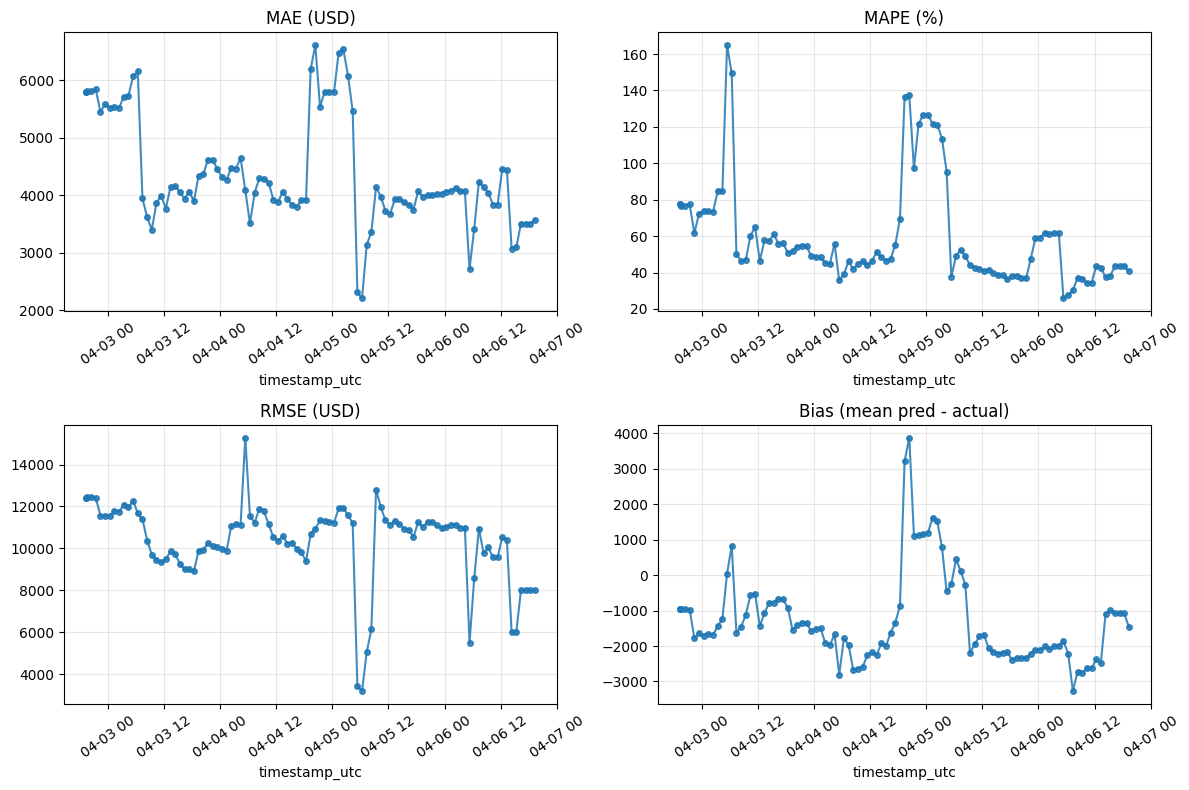

In [109]:
hist = pd.DataFrame()
hist_path = RESULTS / "history" / "metrics_history.csv"

if not RESULTS.is_dir():
    print("No results/ folder.")
elif not hist_path.is_file():
    print("No metrics_history.csv yet.")
else:
    try:
        hist = pd.read_csv(hist_path)
        if "timestamp_utc" in hist.columns:
            hist["timestamp_utc"] = pd.to_datetime(
                hist["timestamp_utc"], utc=True, errors="coerce"
            )
        if "eval_date_local" in hist.columns:
            hist["eval_date_local"] = pd.to_datetime(
                hist["eval_date_local"], errors="coerce"
            ).dt.date.astype(str)
        display(hist.tail(10))
    except Exception as e:
        print(f"Could not load history: {e}")

if hist.empty:
    print("Skip trend plots.")
else:
    if "timestamp_utc" in hist.columns and hist["timestamp_utc"].notna().any():
        x = hist["timestamp_utc"]
        xlabel = "timestamp_utc"
    elif "eval_date_local" in hist.columns:
        x = hist["eval_date_local"].astype(str)
        xlabel = "eval_date_local"
    elif "run_id" in hist.columns:
        x = hist["run_id"].astype(str)
        xlabel = "run_id"
    else:
        x = range(len(hist))
        xlabel = "row index"

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (col, title) in zip(
        axes.ravel(),
        [
            ("mae", "MAE (USD)"),
            ("mape", "MAPE (%)"),
            ("rmse", "RMSE (USD)"),
            ("bias", "Bias (mean pred - actual)"),
        ],
    ):
        if col in hist.columns:
            ax.plot(x, hist[col].astype(float), marker="o", markersize=4, alpha=0.85)
            ax.set_title(title)
            ax.set_xlabel(xlabel)
            ax.tick_params(axis="x", rotation=35)
            ax.grid(True, alpha=0.3)
        else:
            ax.set_visible(False)
    plt.tight_layout()
    plt.show()


In [110]:
# Latest holdout point + trend context (from synced metrics + history)
hist_path = RESULTS / "history" / "metrics_history.csv"
hist_tail = pd.DataFrame()
if hist_path.is_file():
    try:
        hist_tail = pd.read_csv(hist_path)
        if "timestamp_utc" in hist_tail.columns:
            hist_tail["timestamp_utc"] = pd.to_datetime(hist_tail["timestamp_utc"], utc=True, errors="coerce")
            hist_tail = hist_tail.sort_values("timestamp_utc")
        elif "run_id" in hist_tail.columns:
            hist_tail = hist_tail.sort_values("run_id")
    except Exception:
        hist_tail = pd.DataFrame()

mae = metrics.get("mae")
mape = metrics.get("mape")
rmse = metrics.get("rmse")
bias = metrics.get("bias")


def _f(v):
    if v is None or (isinstance(v, float) and v != v):
        return "n/a"
    return f"{float(v):,.2f}"

### Interpretation (trends)

- The latest synced run ends with **MAE = \$3,563.90**, **MAPE = 40.65%**, **RMSE = \$7,999.80**, and **bias = -\$1,462.82**. These should be read against the matching holdout row for the same `run_id`.
- The series is naturally somewhat volatile because each point reflects a new hourly run, often with a slightly different holdout slice.
- **RMSE remains much higher than MAE**, which suggests that while many predictions are reasonably close, a smaller number of larger misses are still pulling RMSE upward.
- **MAPE can rise or fall sharply**, so it should be interpreted alongside MAE rather than on its own, especially when the holdout includes lower-priced vehicles.
- In this window, most of the movement likely reflects changing sample composition and retraining as new listings arrive, so an isolated spike does not by itself indicate model failure.
- **Bias is defined as mean(predicted - actual)**. A **negative bias** means the model is underpredicting prices on average, while a **positive bias** means it is overpredicting.

## Historical interpretability trend

This panel tracks how permutation importance changes across synced runs. It complements the latest-run snapshot by showing whether the model has relied on the same features consistently or whether feature rankings have shifted as the dataset has grown.

**Compact per-run summary (top 3, excerpt)**

,run_id,run_ts,rank_within_run,feature,importance
0,2026040219,2026-04-02 19:31:58.852835+00:00,1.0,mileage_num,1000.678092
1,2026040219,2026-04-02 19:31:58.852835+00:00,2.0,log_mileage,938.453610
2,2026040219,2026-04-02 19:31:58.852835+00:00,3.0,vehicle_age,696.435006
3,2026040220,2026-04-02 20:20:34.968162+00:00,1.0,mileage_num,1000.678092
4,2026040220,2026-04-02 20:20:34.968162+00:00,2.0,log_mileage,938.453610
5,2026040220,2026-04-02 20:20:34.968162+00:00,3.0,vehicle_age,696.435006
6,2026040221,2026-04-02 21:20:43.842401+00:00,1.0,log_mileage,975.985229
7,2026040221,2026-04-02 21:20:43.842401+00:00,2.0,mileage_num,809.289848
8,2026040221,2026-04-02 21:20:43.842401+00:00,3.0,vehicle_age,621.945413
9,2026040222,2026-04-02 22:20:44.305925+00:00,1.0,mileage_num,1086.365018


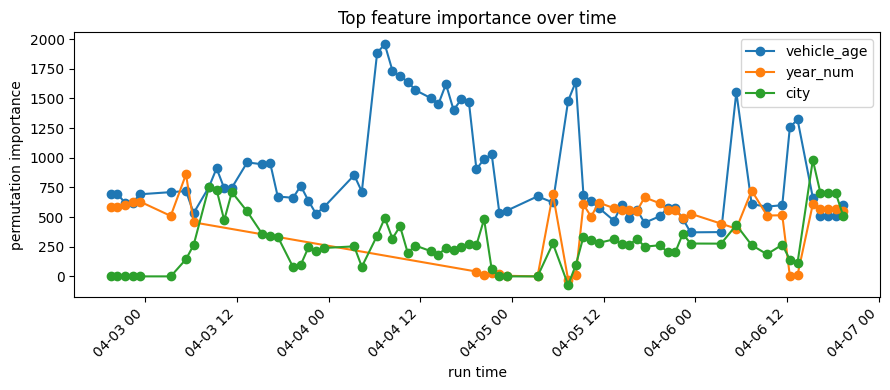

**Importance by run (selected features)**

,vehicle_age,year_num,city
run_ts,,,
2026-04-02 19:31:58.852835+00:00,696.4350,587.9677,0.0000
2026-04-02 20:20:34.968162+00:00,696.4350,587.9677,0.0000
2026-04-02 21:20:43.842401+00:00,621.9454,601.1386,0.0000
2026-04-02 22:20:44.305925+00:00,622.2055,629.3214,0.0000
2026-04-02 23:20:58.771017+00:00,692.1718,629.5300,0.0000
...,...,...,...
2026-04-06 15:21:38.645934+00:00,663.9453,609.1495,980.9252
2026-04-06 16:21:49.164211+00:00,507.5618,563.7820,700.7960
2026-04-06 17:21:48.162084+00:00,507.5618,563.7820,700.7960


In [111]:
import glob
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

_perm_dir = RESULTS / "permutation_importance"
_csv_paths = sorted(glob.glob(str(_perm_dir / "*.csv")))

FEAT_CANDS = ("feature", "Feature", "FEATURE", "feature_name", "Feature_name")
IMP_CANDS = (
    "importance_mean",
    "importance",
    "perm_importance_mean",
    "mean_importance",
    "score",
    "Importance",
)


def _norm_cols(df: pd.DataFrame) -> dict[str, str]:
    return {str(c).strip().lower(): c for c in df.columns}


def _resolve_feat_imp(df: pd.DataFrame) -> tuple[str | None, str | None]:
    nc = _norm_cols(df)
    feat_col = None
    for cand in FEAT_CANDS:
        k = cand.strip().lower()
        if k in nc:
            feat_col = nc[k]
            break
    imp_col = None
    for cand in IMP_CANDS:
        k = cand.strip().lower()
        if k in nc:
            imp_col = nc[k]
            break
    return feat_col, imp_col


def _run_id_from_path(p: Path) -> str | None:
    stem = p.stem
    m = re.match(r"^(\d{10})", stem)
    if m:
        return m.group(1)
    m = re.match(r"^(\d+)", stem)
    return m.group(1) if m else None


def _run_ts_from_id(rid: str) -> pd.Timestamp:
    if not rid or not str(rid).isdigit():
        return pd.NaT
    s = str(rid)
    if len(s) >= 10:
        return pd.to_datetime(s[:10], format="%Y%m%d%H", errors="coerce")
    return pd.NaT


if not _csv_paths:
    display(
        Markdown(
            "_No permutation-importance CSV files found under `results/permutation_importance/`. "
            "Run **Sync model artifacts** after training._"
        )
    )
else:
    long_rows: list[dict] = []
    for file_order, fp_str in enumerate(_csv_paths):
        fp = Path(fp_str)
        try:
            part = pd.read_csv(fp, low_memory=False)
        except Exception as e:
            print(f"Skip {fp.name}: {e}")
            continue
        feat_col, imp_col = _resolve_feat_imp(part)
        if feat_col is None or imp_col is None:
            print(f"Skip {fp.name}: could not resolve feature/importance columns.")
            continue
        nc = _norm_cols(part)
        rid = None
        if "run_id" in nc:
            rid = part[nc["run_id"]].iloc[0] if len(part) else None
        rid = str(rid).strip() if rid is not None and str(rid) not in ("nan", "None") else None
        if not rid:
            rid = _run_id_from_path(fp)
        if not rid:
            rid = f"file_{file_order}"

        sub = part[[feat_col, imp_col]].copy()
        sub.columns = ["feature", "importance"]
        sub["feature"] = sub["feature"].astype(str)
        sub["importance"] = pd.to_numeric(sub["importance"], errors="coerce")
        sub = sub.dropna(subset=["feature", "importance"])
        for _, r in sub.iterrows():
            long_rows.append(
                {
                    "run_id": str(rid),
                    "file_order": file_order,
                    "feature": r["feature"],
                    "importance": float(r["importance"]),
                }
            )

    if not long_rows:
        display(
            Markdown(
                "_Permutation-importance files exist but no usable rows were parsed "
                "(check column names)._"
            )
        )
    else:
        long = pd.DataFrame(long_rows)

        hist_ts = pd.DataFrame()
        hist_path = RESULTS / "history" / "metrics_history.csv"
        if hist_path.is_file():
            try:
                hist_ts = pd.read_csv(hist_path, low_memory=False)
            except Exception:
                hist_ts = pd.DataFrame()

        ts_map: dict[str, pd.Timestamp] = {}
        if not hist_ts.empty and "run_id" in hist_ts.columns:
            h = hist_ts.drop_duplicates(subset=["run_id"], keep="last")
            if "timestamp_utc" in h.columns:
                tcol = pd.to_datetime(h["timestamp_utc"], utc=True, errors="coerce")
                for i, rid in enumerate(h["run_id"].astype(str)):
                    ts_map[str(rid)] = tcol.iloc[i]

        long["run_ts"] = long["run_id"].map(lambda r: ts_map.get(str(r), pd.NaT))
        parsed = long["run_id"].map(_run_ts_from_id)
        long["run_ts"] = long["run_ts"].where(long["run_ts"].notna(), parsed)

        long = long.sort_values(["run_id", "importance", "feature"], ascending=[True, False, True])
        long["rank_within_run"] = long.groupby("run_id", sort=False)["importance"].rank(
            ascending=False, method="first"
        )

        perm_hist_summary = (
            long[long["rank_within_run"] <= 3]
            .sort_values(["run_id", "rank_within_run"])
            .loc[:, ["run_id", "run_ts", "rank_within_run", "feature", "importance"]]
            .reset_index(drop=True)
        )

        meta = (
            long.groupby("run_id", as_index=False)
            .agg(run_ts=("run_ts", "max"), file_order=("file_order", "min"))
        )
        if meta["run_ts"].notna().any():
            meta = meta.sort_values(["run_ts", "file_order", "run_id"], na_position="last")
        else:
            meta = meta.sort_values(["file_order", "run_id"])
        meta["run_id"] = meta["run_id"].astype(str)
        runs_ordered = meta["run_id"].tolist()
        latest_rid = str(meta.iloc[-1]["run_id"])

        top_latest = (
            long[long["run_id"] == latest_rid]
            .sort_values("rank_within_run")
            .head(3)["feature"]
            .astype(str)
            .tolist()
        )

        if len(top_latest) >= 1:
            plot_feats = top_latest[:3]
        else:
            ones = long.loc[long["rank_within_run"] == 1, "feature"].astype(str)
            plot_feats = [f for f, _ in Counter(ones).most_common(3)]

        plot_feats = [f for f in plot_feats if f][:3]

        display(Markdown("**Compact per-run summary (top 3, excerpt)**"))
        display(perm_hist_summary.head(18))

        if not plot_feats:
            display(Markdown("_Could not select features to plot._"))
        else:
            use_ts_x = bool(meta["run_ts"].notna().any())
            if use_ts_x:
                x_by_run = meta.set_index("run_id")["run_ts"].to_dict()
                x_label = "run time"
            else:
                x_by_run = {rid: i for i, rid in enumerate(runs_ordered)}
                x_label = "run order (synced file order)"

            fig, ax = plt.subplots(figsize=(9, 4))
            for feat in plot_feats:
                xs, ys = [], []
                for rid in runs_ordered:
                    hit = long[(long["run_id"] == rid) & (long["feature"] == feat)]
                    if len(hit):
                        xs.append(x_by_run[rid])
                        ys.append(float(hit["importance"].iloc[0]))
                if xs:
                    ax.plot(xs, ys, marker="o", linestyle="-", label=feat)

            ax.set_title("Top feature importance over time")
            ax.set_ylabel("permutation importance")
            ax.set_xlabel(x_label)
            ax.legend(loc="best")
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
            fig.tight_layout()
            plt.show()

            rows_tbl = []
            for rid in runs_ordered:
                row = {"run_id": rid}
                ts = meta.loc[meta["run_id"] == rid, "run_ts"].iloc[0]
                row["run_ts"] = ts
                for feat in plot_feats:
                    hit = long[(long["run_id"] == rid) & (long["feature"] == feat)][
                        "importance"
                    ]
                    row[feat] = float(hit.iloc[0]) if len(hit) else float("nan")
                rows_tbl.append(row)

            tbl = pd.DataFrame(rows_tbl)
            if use_ts_x and tbl["run_ts"].notna().all():
                tbl = tbl.set_index("run_ts").drop(columns=["run_id"])
            elif use_ts_x and tbl["run_ts"].notna().any():
                tbl["_lbl"] = tbl["run_ts"].where(tbl["run_ts"].notna(), tbl["run_id"])
                tbl = tbl.set_index("_lbl").drop(columns=["run_id", "run_ts"])
            else:
                tbl = tbl.set_index("run_id").drop(columns=["run_ts"])

            display(Markdown("**Importance by run (selected features)**"))
            display(tbl.round(4))


### Historical interpretability

- This chart shows whether the model's most important features remain stable as new data arrives.
- Stable lines suggest the model is relying on a consistent signal over time.
- Large swings or rank reversals can indicate changing sample composition, changing market conditions, or increasing usefulness of newly extracted features.
- This is descriptive rather than causal: permutation importance shows which variables were useful to the fitted model, not whether they cause price changes.

## 6. Permutation importance (latest run)

Holdout **permutation importance** measures how much **dollar MAE** worsens when a feature is shuffled (conditional on the fitted pipeline). Higher **importance_mean** ⇒ the model relied more on that input on the holdout slice.

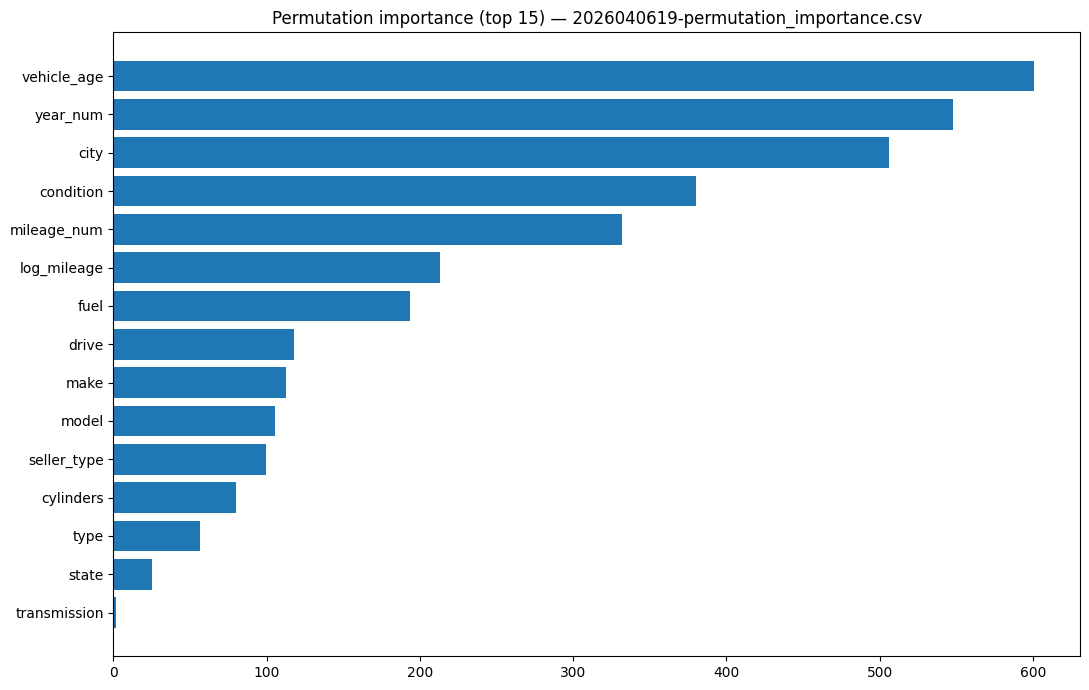

In [112]:
import glob

imp_path = None
if run_id:
    cand = RESULTS / "permutation_importance" / f"{run_id}-permutation_importance.csv"
    if cand.is_file():
        imp_path = cand

if imp_path is None and RESULTS.is_dir():
    all_imp = sorted(
        glob.glob(str(RESULTS / "permutation_importance" / "*-permutation_importance.csv"))
    )
    if all_imp:
        imp_path = Path(all_imp[-1])

if imp_path is None or not imp_path.is_file():
    print("No permutation importance CSV found.")
else:
    try:
        dfi = pd.read_csv(imp_path)
        need = {"feature", "importance_mean"}
        if not need.issubset(dfi.columns):
            print("Unexpected columns in permutation file:", list(dfi.columns))
        else:
            top = dfi.sort_values("importance_mean", ascending=True).tail(15)
            fig, ax = plt.subplots(figsize=(11, 7))
            ax.barh(top["feature"], top["importance_mean"])
            ax.set_title(f"Permutation importance (top 15) — {imp_path.name}")
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Could not plot importance: {e}")


In [113]:
import glob

imp_csv = None
if run_id:
    p = RESULTS / "permutation_importance" / f"{run_id}-permutation_importance.csv"
    if p.is_file():
        imp_csv = p
if imp_csv is None and RESULTS.is_dir():
    all_imp = sorted(glob.glob(str(RESULTS / "permutation_importance" / "*-permutation_importance.csv")))
    if all_imp:
        imp_csv = Path(all_imp[-1])

topn = []
if imp_csv and imp_csv.is_file():
    try:
        idf = pd.read_csv(imp_csv).sort_values("importance_mean", ascending=False)
        topn = idf["feature"].head(6).tolist()
    except Exception:
        topn = []

feat_set = ", ".join(f"`{x}`" for x in topn) if topn else "(see bar chart above)"

### Interpretation (importance)

- In this run, the most important features are **vehicle_age**, **year_num**, **city**, **condition**, **mileage_num**, and **log_mileage**.
- That ranking is economically sensible because **age/year** and **mileage** are core drivers of used-car prices.
- **vehicle_age** and **year_num** are closely related, so their bars should not be interpreted as two separate causal effects. Instead, they show that the model relies heavily on **vehicle age information** overall.
- The high importance of **city** suggests that **local market conditions** matter meaningfully in this sample.
- **Condition** also ranks strongly, which is consistent with vehicle quality affecting price beyond age and mileage alone.
- Lower-ranked features such as **state** and especially **transmission** added relatively little incremental value in this run once the stronger predictors were already included.

## 7. Partial dependence plots (latest run, top 3)

These PDPs do not show price directly in USD. The plots are on the model's log target, as the titles indicate (`log target`), so the y-axis is partial dependence on predicted log-price. Higher values still imply a higher predicted price level after back-transformation, but the scale is relative and multiplicative rather than dollar-additive.

PDPs are directional, not causal, and the rug marks on the x-axis show where the data are concentrated. The tails should be read cautiously because sparse regions can create jagged or flat segments.

Only the three features with the highest holdout permutation importance are exported as PNGs for this run.


**2026040619_pdp_top1_vehicle_age.png**

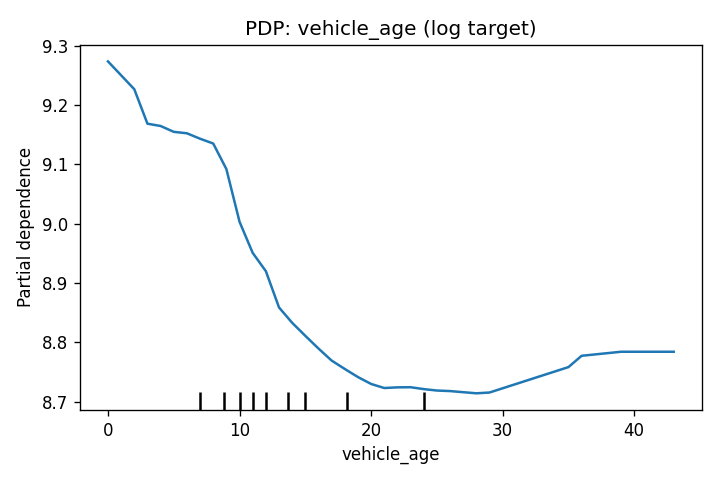

**2026040619_pdp_top2_year_num.png**

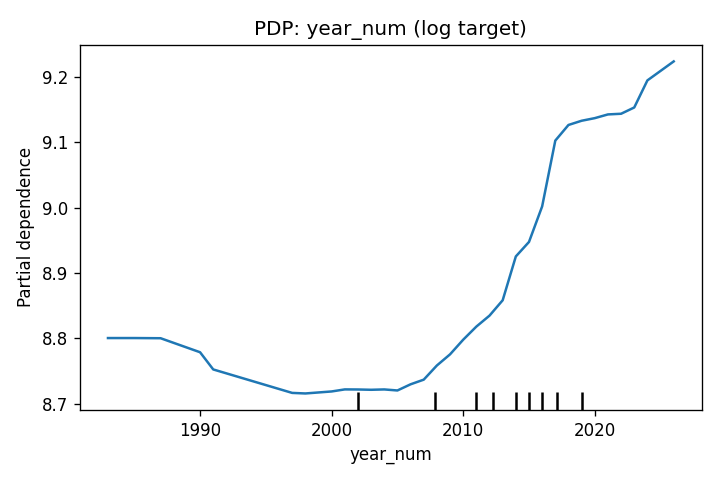

In [114]:
pdp_files = []
if run_id and (RESULTS / "pdp").is_dir():
    pdp_files = sorted((RESULTS / "pdp").glob(f"{run_id}_*.png"))

if not pdp_files and (RESULTS / "pdp").is_dir():
    pdp_files = sorted((RESULTS / "pdp").glob("*.png"))[-3:]

if not pdp_files:
    print("No PDP PNGs in results/pdp/ for this run (train + sync after PDP export).")
elif Image is None:
    print("IPython.display.Image not available; paths:", pdp_files)
else:
    for fp in pdp_files[:3]:
        display(Markdown(f"**{fp.name}**"))
        display(Image(filename=str(fp), width=900))


### Interpretation (PDPs)

- `vehicle_age`: predicted price level is highest for the newest vehicles, drops sharply around roughly 9–10 years old, and keeps drifting downward into the mid-20s. The slight rebound at very old ages is likely a sparse-data effect rather than a strong substantive pattern.
- `year_num`: the mirror image appears here. Newer model years raise the predicted price level, with especially strong gains after about 2008 and again after roughly 2017.
- `mileage_num`: higher mileage lowers the predicted price level, with the decline becoming steeper after about 100k miles and remaining strongly negative through the high-mileage range.
- The PDPs agree with the permutation-importance chart: age/year and mileage are the dominant pricing signals in this run.


## 8. Discussions

- **What improved:** the pipeline compares **four** regressors, **raw vs log** targets, and **tuned** finalists on a **calendar validation** day, then evaluates on a **strict forward** holdout. Artifacts (`model_benchmark.csv`, importance, PDPs) make the choice auditable.
- **What stays hard:** Craigslist asks are noisy; one **calendar day** of holdout can be an easy or brutal slice. **MAPE** will swing when the mix includes many cheap cars.
- **Bias:** read alongside MAE -- it describes systematic shift on that holdout day, not "accuracy" alone.
- **Compared to a single default model:** this workflow documents **why** a specific **(model, target)** pair was selected for each run (via **val_composite** on validation, then holdout metrics for reporting).

- **Artifacts:** `model_benchmark.csv`, **`tuning_trials.csv`** (every randomized trial), holdout **`metrics.json`**, permutation importance, and PDP PNGs under `results/` keep the workflow auditable after sync.


## 9. Conclusions

- **Repro:** train with `dry_run: false`, run **Sync model artifacts**, open this notebook from repo root (or Colab with `NOTEBOOK_REPO_URL`).
- **Read first:** `model_benchmark.csv` + **Final choice** callout above, then holdout table, then trends.

---

**Metadata:** For the latest run, `model_info.json` lists **`feature_notes`**, **`filtering`**, and **`benchmark.feature_variant`** (numeric feature set A / B / C) used when the Cloud Function trained.
